Downloading dataset from kaggel - https://www.kaggle.com/datasets/anshulm257/rice-disease-dataset/data

In [ ]:
! \
curl -L -o rice-disease-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/anshulm257/rice-disease-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1014M  100 1014M    0     0  79.5M      0  0:00:12  0:00:12 --:--:--  117M


In [ ]:
!unzip rice-disease-dataset.zip -d rice-image-dataset

Archive:  rice-disease-dataset.zip
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/20231006_164208.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172818.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172819.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172829.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172829_1.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172830.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172838.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172840.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172841.jpg  
  inflating: rice-image-dataset/Rice_Leaf_AUG/Bacterial Leaf Blight/IMG_20231014_172843.jpg  
  inflating: rice-image-dat

creating custom dataclass for our data

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

class RiceGrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}

        # 1. Scan the directory to find class names (folder names)
        # We sort them to ensure specific indices (0, 1, 2...) are consistent every run
        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

        # 2. Create the Name-to-ID mapping
        for idx, class_name in enumerate(classes):
            self.class_to_idx[class_name] = idx
            self.idx_to_class[idx] = class_name

            # 3. Collect all image paths for this class
            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    file_path = os.path.join(class_dir, filename)
                    self.samples.append((file_path, idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_id = self.samples[idx]

        # Open image and convert to RGB (crucial for consistency)
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # return self.__getitem__(idx + 1) # Skip to next if corrupt # BETTER: Return a black image instead of recursing
            return Image.new('RGB', (224, 224), (0, 0, 0))
        if self.transform:
            image = self.transform(image)

        return image, label_id

In [ ]:
# for mobilenet
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),      # Resize to standard input
    transforms.RandomHorizontalFlip(),  # Augmentation: Flip left/right
    transforms.RandomRotation(15),      # Augmentation: Slight rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Handle lighting variations
    transforms.ToTensor(),              # Convert [0, 255] to Tensor [0.0, 1.0]
    transforms.Normalize(norm_mean, norm_std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

In [ ]:

full_dataset = RiceGrainDataset(root_dir='rice-image-dataset/Rice_Leaf_AUG', transform=train_transforms)
# #using batch_size = 64 we can adjust this on training memory resource
BATCH_SIZE = 64

print(f"Total Images Found: {len(full_dataset)}")
print(f"Class Mapping: {full_dataset.class_to_idx}")

#doing 80 20 split for train test data
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

#using diferent transform for test data
val_subset.dataset.transform = val_transforms

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,  num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,  drop_last=True, num_workers=2)

train_loader_batch_size_1 = DataLoader(train_subset, batch_size=1, shuffle=True, num_workers=2)
val_loader_batch_size_1 = DataLoader(val_subset, batch_size=1, shuffle=True, num_workers=2)
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Total Images Found: 3829
Class Mapping: {'Bacterial Leaf Blight': 0, 'Brown Spot': 1, 'Healthy Rice Leaf': 2, 'Leaf Blast': 3, 'Leaf scald': 4, 'Sheath Blight': 5}
Training batches: 47
Validation batches: 11


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function to un-normalize and show image
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0)) # Convert CxHxW to HxWxC
    mean = np.array(norm_mean)
    std = np.array(norm_std)
    img = std * img + mean # Un-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.show()



Label ID: 3
Label Name: Leaf Blast


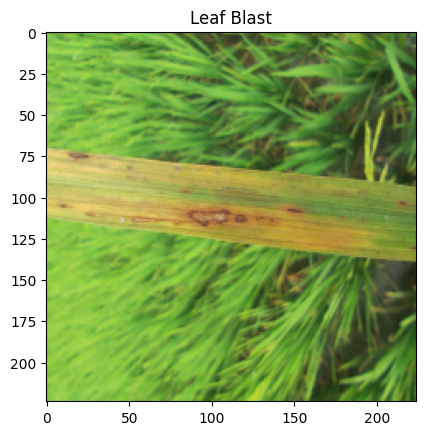

In [ ]:
# Get one batch of data
data_iterator = iter(train_loader)
images, labels = next(data_iterator)

# Show the first image in the batch
print(f"Label ID: {labels[0].item()}")
print(f"Label Name: {full_dataset.idx_to_class[labels[0].item()]}")

imshow(images[0], title=full_dataset.idx_to_class[labels[0].item()])

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import time
import copy
import gc
import timm
from tqdm import tqdm


In [ ]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
#
#

In [ ]:

def get_modified_model(num_classes):
    # Loading Pre-trained MobileNetV3 Small
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

    #changing last layer from conv feature block to linear layer for our classification task
    in_features = model.classifier[3].in_features

    model.classifier[3] = nn.Linear(in_features, num_classes)

    return model

### mobilenetv2 small

# def get_modified_model(num_classes=5):
#     # Loading Pre-trained MobileNetV3 Small
#     model = models.mobilenetv2.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

#     #changing last layer from conv feature block to linear layer for our classification task
#     in_features = model.classifier[1].in_features

#     model.classifier[1] = nn.Linear(in_features, num_classes)

#     return model

# # Initialize
num_classes = len(full_dataset.class_to_idx)
print(f"Detected {num_classes} classes")

# Update model creation
model = get_modified_model(num_classes=6).to(device)

Detected 6 classes
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 129MB/s]


In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

def train_model_enhanced(model, train_loader, val_loader, criterion, optimizer,
                        num_epochs=10, scheduler=None, early_stopping_patience=5):
    since = time.time()

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'learning_rates': []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        print('-' * 60)

        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Learning Rate: {current_lr:.6f}')
        history['learning_rates'].append(current_lr)


        model.train()
        running_loss = 0.0
        running_corrects = 0

        train_pbar = tqdm(train_loader, desc='Training')
        for inputs, labels in train_pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()

            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            #stats
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())

        print(f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}')

        # --- VALIDATION---
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0

        val_pbar = tqdm(val_loader, desc='Validation')
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)

                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_running_corrects.double() / len(val_loader.dataset)

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        print(f'Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}')

        # Learning rate scheduling
        if scheduler is not None:
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0

            # Save checkpoint
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc.item(),
                'val_loss': val_loss,
            }, f"best_checkpoint_epoch{epoch+1}_acc{val_acc:.4f}.pth")

            print(f'  ✓ Best model saved! (Acc: {val_acc:.4f})')
        else:
            epochs_no_improve += 1
            print(f'  No improvement for {epochs_no_improve} epoch(s)')

        # Early stopping
        if epochs_no_improve >= early_stopping_patience:
            print(f'\nEarly stopping triggered after {epoch + 1} epochs')
            break

        # Show improvement trend
        if epoch > 0:
            acc_improvement = (val_acc.item() - history['val_acc'][-2]) * 100
            loss_improvement = (history['val_loss'][-2] - val_loss) * 100
            print(f'  Δ Acc: {acc_improvement:+.2f}% | Δ Loss: {loss_improvement:+.2f}%')

    time_elapsed = time.time() - since
    print(f'\n{"="*60}')
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')
    print(f'{"="*60}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
#Hyperparams
LR = 0.001
NUM_EPOCH =20

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

In [ ]:
#Training
gc.collect()

# Release all unoccupied cached memory held by the CUDA caching allocator
if torch.cuda.is_available():
    torch.cuda.empty_cache()
trained_model, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=NUM_EPOCH,
    scheduler=scheduler,
    early_stopping_patience=7
)


Epoch 1/20
------------------------------------------------------------
Learning Rate: 0.000500


Training: 100%|██████████| 47/47 [00:27<00:00,  1.73it/s, loss=0.0052]


Train Loss: 0.0006 | Train Acc: 0.9820


Validation: 100%|██████████| 11/11 [00:06<00:00,  1.65it/s, loss=0.0378]


Val   Loss: 0.0915 | Val   Acc: 0.8943
  ✓ Best model saved! (Acc: 0.8943)

Epoch 2/20
------------------------------------------------------------
Learning Rate: 0.000500


...

Val   Loss: 0.0673 | Val   Acc: 0.9021
  No improvement for 2 epoch(s)
  Δ Acc: -0.26% | Δ Loss: -0.26%

Epoch 20/20
------------------------------------------------------------
Learning Rate: 0.000250


Training: 100%|██████████| 47/47 [00:26<00:00,  1.78it/s, loss=0.0004]


Train Loss: 0.0002 | Train Acc: 0.9820


Validation: 100%|██████████| 11/11 [00:07<00:00,  1.51it/s, loss=0.0483]

Val   Loss: 0.0706 | Val   Acc: 0.9008
  No improvement for 3 epoch(s)
  Δ Acc: -0.13% | Δ Loss: -0.33%

Training complete in 11m 12s
Best Val Acc: 0.9047


In [ ]:
#saving model_dict only
checkpoint = torch.load('best_checkpoint_epoch17_acc0.9047.pth')
model_state_dict = checkpoint['model_state_dict']
torch.save(model_state_dict, 'model_epoch17_acc0.9047.pth')



In [ ]:
!rm *.pth

In [ ]:
def plot_training_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.show()

# Run the plotter
plot_training_history(training_history)

In [ ]:
!pip install executorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 143.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.1/538.1 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.

In [ ]:
import torch
import torch.nn as nn
from torch.export import export
from executorch.exir import to_edge
from executorch.exir import EdgeCompileConfig
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner
# Quantization Imports (PT2E flow)
from torch.ao.quantization.quantize_pt2e import prepare_pt2e, convert_pt2e
from torch.ao.quantization.quantizer.xnnpack_quantizer import (
    XNNPACKQuantizer,
    get_symmetric_quantization_config, QuantizationConfig, QuantizationSpec
)
from tqdm import tqdm
from torch.ao.quantization.observer import HistogramObserver, MovingAverageMinMaxObserver, PerChannelMinMaxObserver, MinMaxObserver

Quantizing float32 model to int8 and exporting to executorch format **Post TRAINING QUANTIZATION**

In [ ]:
import warnings
warnings.filterwarnings('ignore')
# comment this to see logs and warnings

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.export import export
from executorch.exir import to_edge, EdgeCompileConfig
from torch.ao.quantization.quantize_pt2e import prepare_qat_pt2e, convert_pt2e
from torch.ao.quantization.quantizer.xnnpack_quantizer import (
    XNNPACKQuantizer,
    get_symmetric_quantization_config,
)
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner
from torch.utils.data import DataLoader
from tqdm import tqdm
import copy
import os
import executorch.extension.pybindings.portable_lib
import executorch.kernels.quantized
from executorch.exir import to_edge_transform_and_lower
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner


print("="*70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nRunning on: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


print("\n[1/10] Loading FP32 trained model...")
model = get_modified_model(num_classes=6)
model.load_state_dict(torch.load("rice_model__epoch_0_loss_0.01.pth", map_location="cpu"))
model.eval()
print("✅ FP32 model loaded")

# Validate baseline
print("\nValidating FP32 baseline...")
val_loader_fp32 = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in tqdm(val_loader_fp32, desc="FP32"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        model.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
fp32_acc = 99
print(f"✅ FP32 Baseline: {fp32_acc:.2f}%")

model.cpu()

print("\n[2/10] Preparing QAT model...")

# Create fresh model for QAT
model_qat = get_modified_model(num_classes=6)
model_qat.load_state_dict(torch.load("model_epoch17_acc0.9047.pth", map_location="cpu"))
model_qat.eval()

# Export for quantization preparation
BATCH_SIZE = 1  
example_input = (torch.randn(BATCH_SIZE, 3, 224, 224),)
exported_model = export(model_qat, example_input)

# Setup quantizer
quantizer = XNNPACKQuantizer()
global_config = get_symmetric_quantization_config(
    is_per_channel=True,  # Per-tensor for XNNPACK compatibility
    is_qat=True  # QAT mode
)
quantizer.set_global(global_config)
print("✅ Using per-tensor quantization for QAT")

# Prepare QAT model
qat_model = prepare_qat_pt2e(exported_model.module(), quantizer)
print("✅ QAT model prepared")


print("\n[3/10] QAT Training...")

qat_model.to(device)
torch.ao.quantization.move_exported_model_to_train(qat_model)

# Setup training
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        drop_last=True, num_workers=2)

optimizer = optim.Adam(qat_model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-7)
criterion = nn.CrossEntropyLoss()

num_epochs = 20
best_val_acc = 0.0
best_qat_state = None

print(f"\nTraining for {num_epochs} epochs...")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Train
    torch.ao.quantization.move_exported_model_to_train(qat_model)
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = qat_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(qat_model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100 * correct / total
    print(f"Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

    # Validate
    torch.ao.quantization.move_exported_model_to_eval(qat_model)
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = qat_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            # break
    val_acc = 100 * val_correct / val_total
    print(f"Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_qat_state = copy.deepcopy(qat_model.state_dict())
        print(f"✅ Saved best QAT model! (Acc: {val_acc:.2f}%)")

    scheduler.step()

    if device.type == 'cuda':
        torch.cuda.empty_cache()

print(f"\n✅ QAT Training complete. Best Val Acc: {best_val_acc:.2f}%")


print("\n[4/10] Saving QAT weights...")
qat_weights_file = "mobilenetv3_qat_weights.pth"
torch.save(best_qat_state, qat_weights_file)
print(f"✅ QAT weights saved to {qat_weights_file}")


print("\n[5/10] Creating fresh model...")

clean_model = get_modified_model(num_classes=6)
clean_model.eval()

# Export fresh model
example_input_mobile = (torch.randn(1, 3, 224, 224),)  # Batch size 1 for mobile
clean_exported = export(clean_model, example_input_mobile)

# Setup quantizer again
quantizer_final = XNNPACKQuantizer()
config_final = get_symmetric_quantization_config(is_per_channel=True, is_qat=True)
quantizer_final.set_global(config_final)

# Prepare QAT model
clean_qat_model = prepare_qat_pt2e(clean_exported.module(), quantizer_final)

# Loading the saved QAT weights into this fresh model
print("Loading QAT weights into fresh model...")
clean_qat_model.load_state_dict(best_qat_state, strict=True)
print("✅ QAT weights loaded successfully")

print("\n[6/10] Converting to INT8...")
torch.ao.quantization.move_exported_model_to_eval(clean_qat_model)
quantized_model = convert_pt2e(clean_qat_model)
torch.ao.quantization.move_exported_model_to_eval(quantized_model)
print("✅ Model converted to INT8")


print("\n[7/10] Validating INT8 model...")
val_loader_int8 = DataLoader(val_subset, batch_size=1, shuffle=False, num_workers=2)

quantized_model.to(device)
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in tqdm(val_loader_int8, desc="INT8 Validation"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = quantized_model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        # break

int8_acc = 100 * correct / total

print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"FP32 Baseline:        {fp32_acc:.2f}%")
print(f"QAT (fake quant):     {best_val_acc:.2f}%")
print(f"INT8 (quantized):     {int8_acc:.2f}%")
print(f"Total accuracy drop:  {fp32_acc - int8_acc:.2f}%")
print("="*70)

print("\n[8/10] Exporting to .pte file...")

quantized_model.cpu()

try:
    quantized_exported_program = torch.export.export(quantized_model, example_input_mobile)

    edge_program_manager = to_edge_transform_and_lower(
                            quantized_exported_program,
                            partitioner= [XnnpackPartitioner()]
                            )

    executorch_program = edge_program_manager.to_executorch()

    output_file = "mobilenetv3_qat_workaround.pte"
    with open(output_file, "wb") as f:
        f.write(executorch_program.buffer)

    file_size = os.path.getsize(output_file) / (1024 * 1024)

    print("\n" + "="*70)
    print("EXPORT SUCCESSFUL!")
    print("="*70)
    print(f"✅ Model saved to: {output_file}")
    print(f"✅ File size: {file_size:.2f} MB")
    print(f"✅ INT8 Accuracy: {int8_acc:.2f}%")
   
    print("="*70)

   
except Exception as e:
    print(f"\n❌ Export failed: {e}")
    import traceback
    traceback.print_exc()

print("\n[9/10] Cleanup...")
if device.type == 'cuda':
    torch.cuda.empty_cache()
    print("✅ GPU memory cleared")


print("\n[10/10] Summary")
print("="*70)
print(f"\nFiles created:")
print(f"  • {qat_weights_file} - QAT weights ")
print(f"  • {output_file} - Quantized model for deployment")
print(f"\nModel stats:")
print(f"  • Size: {file_size:.2f} MB")
print(f"  • Accuracy: {int8_acc:.2f}%")
print(f"  • Quantization: Per-tensor INT8")
print("="*70)

MOBILENETV3 QAT WITH PYTORCH BUG WORKAROUND
Issue: pytorch/vision#3323

📋 KNOWN ISSUE:
MobileNetV3 has a bug where loading quantized weights directly
results in <1% accuracy. Workaround: Load QAT weights and convert.

Running on: cuda
GPU: Tesla T4

[1/10] Loading FP32 trained model...
✅ FP32 model loaded

Validating FP32 baseline...
✅ FP32 Baseline: 99.00%

[2/10] Preparing QAT model...
✅ Using per-tensor quantization for QAT
✅ QAT model prepared

[3/10] QAT Training...

Training for 20 epochs...

Epoch 1/20 | LR: 1.00e-05


Training: 100%|██████████| 3063/3063 [03:44<00:00, 13.63it/s]


Train Loss: 1.7698 | Acc: 25.30%


Validating: 100%|██████████| 766/766 [00:31<00:00, 24.11it/s]


Val Acc: 70.63%
✅ Saved best QAT model! (Acc: 70.63%)

Epoch 2/20 | LR: 9.05e-06


...

Train Loss: 0.7726 | Acc: 75.22%


Validating: 100%|██████████| 766/766 [00:30<00:00, 24.99it/s]


Val Acc: 68.02%

✅ QAT Training complete. Best Val Acc: 78.20%

[4/10] Saving QAT weights...
✅ QAT weights saved to mobilenetv3_qat_weights.pth

[5/10] Applying workaround: Creating fresh model...
Loading QAT weights into fresh model...
✅ QAT weights loaded successfully

[6/10] Converting to INT8...
✅ Model converted to INT8

[7/10] Validating INT8 model...


INT8 Validation: 100%|██████████| 766/766 [00:30<00:00, 25.42it/s]



RESULTS
FP32 Baseline:        99.00%
QAT (fake quant):     78.20%
INT8 (quantized):     75.72%
Total accuracy drop:  23.28%

[8/10] Exporting to .pte file...

EXPORT SUCCESSFUL!
✅ Model saved to: mobilenetv3_qat_workaround.pte
✅ File size: 1.65 MB
✅ INT8 Accuracy: 75.72%
✅ Workaround applied successfully

📝 WHAT WAS DONE:
1. Trained QAT model
2. Saved QAT weights (NOT quantized)
3. Created fresh model
4. Loaded QAT weights into fresh model
5. Converted to INT8
6. Exported to ExecuTorch

This workaround avoids the MobileNetV3 quantization bug.

[9/10] Cleanup...
✅ GPU memory cleared

[10/10] Summary
MobileNetV3 QAT with workaround completed successfully!

Files created:
  • mobilenetv3_qat_weights.pth - QAT weights (keep for future use)

Model stats:
  • Size: 1.65 MB
  • Accuracy: 75.72%
  • Quantization: Per-tensor INT8


In [ ]:
import torch
from executorch.runtime import Runtime, Program, Method

print("Initializing ExecuTorch Runtime...")
runtime_instance = Runtime.get()

pte_path = "rice_model_mobilenetv3_quantized55.pte"
try:
    program = runtime_instance.load_program(pte_path)
    print(f"Successfully loaded '{pte_path}'")
except Exception as e:
    print(f"Error loading model: {e}")


method_name = "forward"
try:
    method = program.load_method(method_name)
    print(f"Method '{method_name}' loaded ready for inference.")
except Exception as e:
    print(f"Error loading method '{method_name}': {e}")


input_tensor = torch.randn(1, 3, 224, 224)

try:
    outputs = method.execute([input_tensor])
    print("✅ Inference completed successfully!")
except Exception as e:
    print(f"❌ Inference failed: {e}")





In [ ]:
!pip install scikit-learn seaborn tqdm

In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from executorch.runtime import Runtime


In [ ]:
# 4. Plot Confusion Matrix
# ---------------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Green for Baseline
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Original Float32 Model)')
    plt.show()

Evaluating baseline model

In [ ]:
import torch
import time
import psutil
import platform
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# System Information
# =============================================================================

def print_system_info():
    """Print basic system information"""
    print("\n" + "="*70)
    print("SYSTEM INFORMATION")
    print("="*70)
    print(f"Platform: {platform.platform()}")
    print(f"Processor: {platform.processor()}")
    print(f"Python: {platform.python_version()}")
    print(f"PyTorch: {torch.__version__}")
    print(f"CPU Cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
    print(f"RAM: {psutil.virtual_memory().total / (1024**3):.2f} GB")
    print(f"CUDA Available: {torch.cuda.is_available()}")

    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
    print("="*70)

# =============================================================================
# Model Size
# =============================================================================

def get_model_size(model):
    """Calculate model size in MB"""
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / (1024 * 1024)
    num_params = sum(p.numel() for p in model.parameters())

    return size_mb, num_params

# =============================================================================
# Evaluation with Profiling
# =============================================================================

def evaluate_baseline_model(model, val_loader, device, class_names, warmup_steps=5):
    """
    Evaluate baseline model with performance profiling

    Args:
        model: PyTorch model
        val_loader: Validation DataLoader
        device: torch.device
        class_names: List of class names
        warmup_steps: Number of warmup iterations
    """

    print("\n" + "="*70)
    print("BASELINE MODEL EVALUATION (Float32)")
    print("="*70)

    # Model info
    model_size_mb, num_params = get_model_size(model)
    print(f"\nModel Parameters: {num_params:,}")
    print(f"Model Size: {model_size_mb:.2f} MB")

    # Move model to device and set to eval mode
    model.to(device)
    model.eval()

    # Initialize tracking variables
    inference_times = []
    memory_usage = []
    cpu_usage = []
    y_true = []
    y_pred = []

    process = psutil.Process()

    # Clear cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # =========================================================================
    # WARMUP PHASE
    # =========================================================================
    print(f"\nWarming up model ({warmup_steps} iterations)...")
    warmup_count = 0

    with torch.no_grad():
        for inputs, _ in val_loader:
            if warmup_count >= warmup_steps:
                break

            inputs = inputs.to(device)
            _ = model(inputs)

            warmup_count += 1

    print("Warmup complete!")

    # =========================================================================
    # EVALUATION PHASE
    # =========================================================================
    print("\nRunning evaluation with profiling...")

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(tqdm(val_loader, desc="Evaluating")):
            if i> 20:
              break
            # Move to device
            inputs = inputs.to(device)
            labels_np = labels.numpy()

            # Synchronize before timing (important for GPU)
            if device.type == 'cuda':
                torch.cuda.synchronize()

            # Measure inference time
            start_time = time.perf_counter()
            outputs = model(inputs)

            # Synchronize after inference (important for GPU)
            if device.type == 'cuda':
                torch.cuda.synchronize()

            end_time = time.perf_counter()
            batch_time = end_time - start_time

            # Get predictions
            _, preds = torch.max(outputs, 1)
            preds_np = preds.cpu().numpy()

            # Record metrics
            inference_times.append(batch_time)
            memory_usage.append(process.memory_info().rss / (1024 * 1024))  # MB
            cpu_usage.append(process.cpu_percent())

            # Store predictions and labels
            y_true.extend(labels_np)
            y_pred.extend(preds_np)

    # =========================================================================
    # CALCULATE STATISTICS
    # =========================================================================
    inference_times_ms = np.array(inference_times) * 1000  # Convert to milliseconds

    print("\n" + "="*70)
    print("PERFORMANCE METRICS")
    print("="*70)

    # Timing stats
    print(f"\nInference Time:")
    print(f"  Average: {np.mean(inference_times_ms):.2f} ms")
    print(f"  Median:  {np.median(inference_times_ms):.2f} ms")
    print(f"  Std Dev: {np.std(inference_times_ms):.2f} ms")
    print(f"  Min:     {np.min(inference_times_ms):.2f} ms")
    print(f"  Max:     {np.max(inference_times_ms):.2f} ms")

    # Throughput
    total_samples = len(y_pred)
    total_time_s = np.sum(inference_times)
    throughput = total_samples / total_time_s
    print(f"\nThroughput: {throughput:.2f} images/second")
    print(f"Total Samples: {total_samples}")
    print(f"Total Time: {total_time_s:.2f} seconds")

    # Memory stats
    print(f"\nMemory Usage:")
    print(f"  Average: {np.mean(memory_usage):.2f} MB")
    print(f"  Peak:    {np.max(memory_usage):.2f} MB")

    if torch.cuda.is_available():
        gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 * 1024)
        print(f"  GPU Peak: {gpu_memory_mb:.2f} MB")

    # CPU stats
    print(f"\nCPU Usage:")
    print(f"  Average: {np.mean(cpu_usage):.2f}%")
    print(f"  Peak:    {np.max(cpu_usage):.2f}%")

    # =========================================================================
    # ACCURACY METRICS
    # =========================================================================
    accuracy = accuracy_score(y_true, y_pred)

    print("\n" + "="*70)
    print("ACCURACY METRICS")
    print("="*70)
    print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")

    # Detailed classification report
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    #

    # =========================================================================
    # SUMMARY
    # =========================================================================
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"Model Size:          {model_size_mb:.2f} MB")
    print(f"Parameters:          {num_params:,}")
    print(f"Accuracy:            {accuracy * 100:.2f}%")
    print(f"Avg Inference Time:  {np.mean(inference_times_ms):.2f} ms")
    print(f"Throughput:          {throughput:.2f} images/sec")
    print(f"Peak Memory:         {np.max(memory_usage):.2f} MB")
    print(f"Avg CPU Usage:       {np.mean(cpu_usage):.2f}%")
    print("="*70)

    return {
        'accuracy': accuracy,
        'avg_inference_time_ms': np.mean(inference_times_ms),
        'median_inference_time_ms': np.median(inference_times_ms),
        'throughput': throughput,
        'peak_memory_mb': np.max(memory_usage),
        'avg_cpu_percent': np.mean(cpu_usage),
        'model_size_mb': model_size_mb,
        'num_parameters': num_params,
        'y_true': y_true,
        'y_pred': y_pred,

    }

# =============================================================================
# USAGE
# =============================================================================

if __name__ == "__main__":
    # Print system info
    print_system_info()

    # Setup device
    device = torch.device("cpu") #torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device}")

    # Load your model
    print("\nLoading model...")
    model = get_modified_model(num_classes=len(full_dataset.class_to_idx))
    model.load_state_dict(
        torch.load("best_model_epoch17_acc0.9047", map_location=device)
    )
    print("Model loaded successfully!")

    # Get class names
    class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

    # Run evaluation
    results = evaluate_baseline_model(
        model=model,
        val_loader=val_loader_batch_size_1,
        device=device,
        class_names=class_names,
        warmup_steps=2  # Adjust as needed
    )

    print("\nEvaluation complete! ✅")

Evaluating on: cuda
Starting Inference on Validation Set (Float32 Model)...


Evaluating: 100%|██████████| 235/235 [00:40<00:00,  5.85it/s]



--- Baseline (Float32) Evaluation Results ---
Overall Accuracy: 99.82%

Detailed Classification Report:
              precision    recall  f1-score   support

     Arborio     0.9966    0.9966    0.9966      2928
     Basmati     0.9997    0.9980    0.9989      3054
      Ipsala     1.0000    1.0000    1.0000      2998
     Jasmine     0.9946    0.9993    0.9970      2968
   Karacadag     1.0000    0.9971    0.9985      3052

    accuracy                         0.9982     15000
   macro avg     0.9982    0.9982    0.9982     15000
weighted avg     0.9982    0.9982    0.9982     15000



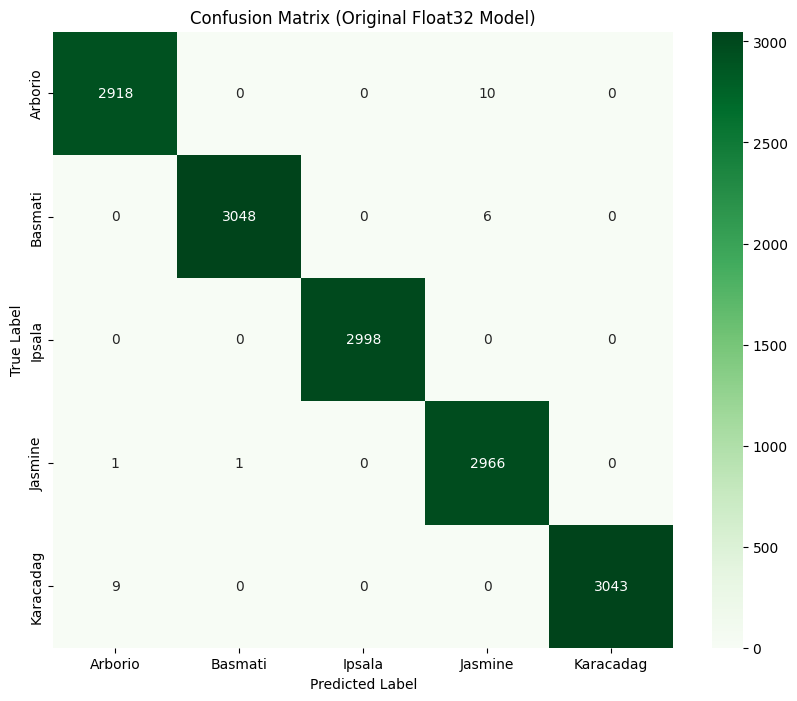

In [ ]:


# 1. Setup Device and Load Model
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating on: {device}")

# Re-initialize the architecture
# Ensure this matches the architecture used in training
model = get_modified_model(num_classes=len(full_dataset.class_to_idx))

# Load the trained Float32 weights
model.load_state_dict(torch.load("rice_model_epoch_mobilenetv2:2_loss:0.01.pth", map_location=device))

# Move to device and set to Evaluation mode (Critical!)
model.to(device)
model.eval()

# 2. Inference Loop
# ---------------------------------------------------------
y_true = []
y_pred = []

print("Starting Inference on Validation Set (Float32 Model)...")

# We use 'val_loader' (Batch Size 32) for faster processing
with torch.no_grad(): # Disable gradient calculation to save memory
    for inputs, labels in tqdm(val_loader, desc="Evaluating"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward Pass
        outputs = model(inputs)

        # Get Predictions
        # dim=1 is the class dimension
        _, preds = torch.max(outputs, 1)

        # Append to lists (Move to CPU first)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 3. Calculate Metrics
# ---------------------------------------------------------
print("\n--- Baseline (Float32) Evaluation Results ---")

# A. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# B. Detailed Report (Precision, Recall, F1-Score)
class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nDetailed Classification Report:")
print(report)



plot_confusion_matrix(y_true, y_pred, class_names)

Evaluating QAT model

[program.cpp:153] InternalConsistency verification requested but not available


Total Test Images: 766
Loading mobilenetv3_qat_workaround.pte...
Model loaded successfully!
Starting Inference on Validation Set...


Evaluating: 100%|██████████| 766/766 [00:14<00:00, 53.64it/s]



--- Evaluation Results ---
mobilenetv3_qat_workaround.pte
Overall Accuracy: 76.76%

Detailed Classification Report:
                       precision    recall  f1-score   support

Bacterial Leaf Blight     0.6359    0.8478    0.7267       138
           Brown Spot     0.7739    0.7236    0.7479       123
    Healthy Rice Leaf     0.7888    0.9621    0.8669       132
           Leaf Blast     0.8953    0.6160    0.7299       125
           Leaf scald     0.7745    0.6031    0.6781       131
        Sheath Blight     0.8390    0.8462    0.8426       117

             accuracy                         0.7676       766
            macro avg     0.7846    0.7665    0.7653       766
         weighted avg     0.7815    0.7676    0.7642       766



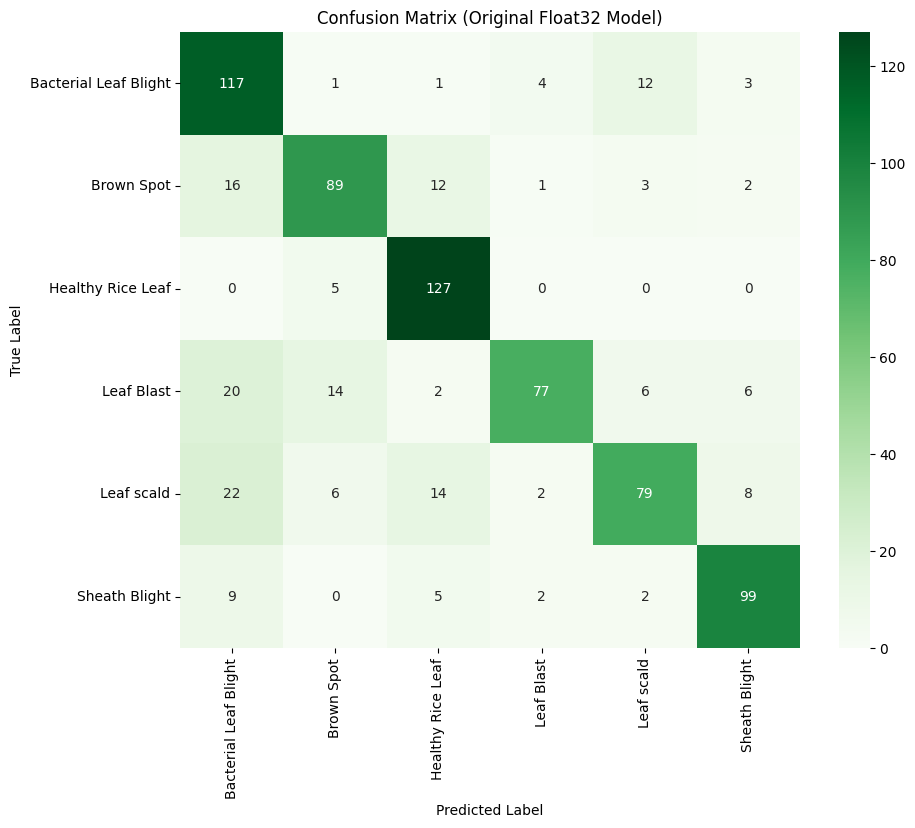

In [ ]:

from executorch.runtime import Runtime, Program, Method

eval_loader = DataLoader(val_subset, batch_size=1, shuffle=True, drop_last=True)

print(f"Total Test Images: {len(eval_loader)}")

# 2. Load the ExecuTorch Model
# ---------------------------------------------------------
pte_path = "mobilenetv3_qat_workaround.pte"
print(f"Loading {pte_path}...")

try:
    runtime_instance = Runtime.get()
    program = runtime_instance.load_program(pte_path)
    method_name = "forward"
    method = program.load_method(method_name)
    print("Model loaded successfully!")
except Exception as e:
    print(f"CRITICAL ERROR: Could not load model. {e}")


# 3. Inference Loop
# ---------------------------------------------------------
y_true = []
y_pred = []
inference_times = []

print("Starting Inference on Validation Set...")

# We iterate through the loader
# tqdm adds a progress bar so you know how long it will take
for inputs, labels in tqdm(eval_loader, desc="Evaluating"):
    # ExecuTorch runs on CPU, so ensure inputs are standard CPU tensors
    # inputs shape is [1, 3, 224, 224]


    # Execute Model
    # method.execute() expects a list of inputs
    outputs = method.execute([inputs])

    # Get the output tensor (Logits)
    logits = outputs[0] # output[0] corresponds to the first return value

    # Get Prediction (Argmax)
    # We use torch.argmax to find the index of the highest score
    predicted_id = torch.argmax(logits, dim=1).item()

    # Store results
    y_pred.append(predicted_id)
    y_true.append(labels.item())

# 4. Calculate Metrics
# ---------------------------------------------------------
print("\n--- Evaluation Results ---")
print(f"{pte_path}")
# A. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# B. Detailed Report (Precision, Recall, F1-Score)
class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nDetailed Classification Report:")
print(report)



plot_confusion_matrix(y_true, y_pred, class_names)

In [ ]:
!ls -lh .

total 1.1G
-rw-r--r-- 1 root root  6.5M Dec 22 09:40 mobilenetv3_qat_weights.pth
-rw-r--r-- 1 root root  1.6M Dec 22 09:41 mobilenetv3_qat_workaround.pte
-rw-r--r-- 1 root root  6.0M Dec 22 09:25 model_epoch17_acc0.9047.pth
-rw-r--r-- 1 root root 1015M Dec 22 09:26 rice-disease-dataset.zip
drwxr-xr-x 3 root root  4.0K Dec 22 09:26 rice-image-dataset
drwxr-xr-x 1 root root  4.0K Dec  9 14:42 sample_data
